List of theoretical Brown Dwarf (BD) cooling models found in literature:

- [AMES-Dusty 2000](https://cds.cern.ch/record/440166/files/0005557.pdf)
- [AMES-Cond 2003](https://www.aanda.org/articles/aa/pdf/2003/17/aa3343.pdf)
- [Saumon & Marley '08 (SM08)](https://arxiv.org/abs/0808.2611)
- [BT-Settl Model 2014](https://ui.adsabs.harvard.edu/abs/2014IAUS..299..271A/abstract) and [this](https://ui.adsabs.harvard.edu/abs/2014ASInC..11...33A/abstract)
- [Fernandes + '19](https://arxiv.org/pdf/1906.05626.pdf)
- [ATMO 2020](https://arxiv.org/abs/2003.13717), data can be found  [here](http://perso.ens-lyon.fr/isabelle.baraffe/ATMO2020/)
- [Sonora](https://arxiv.org/pdf/2107.07434.pdf) --> section 2.6: brief review of models in literature

Apparently there are two families of models: those of the Lyon group and those of the Saumon & Marley group

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.constants import c, R_jup, M_jup, G, GM_jup, sigma_sb, M_sun, L_sun, R_sun
import astropy.units as u
from scipy.interpolate import interp1d, interp2d, griddata
import cmocean
from scipy.stats import loguniform
import sys
sys.path.append("../python/")
from utils import temperature, heat, temperature_withDM
import bokeh.palettes
import _corner
import imp
imp.reload(_corner)
from _corner import corner
import pickle
from scipy.stats import gaussian_kde
import glob

from matplotlib import rc
rc('font', family='times new roman', size=18.)

### Saumon & Marley '08 (fig 2)

In [48]:
age  = {}
logL = {}
L    = {}
M    = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
Teff = {}

evolution_SM08 = {}

for mass in M:
    data = np.genfromtxt("/Users/mariabenito/Dropbox/exoplanets/DM/python/cluster/data/saumon_marley_fig2_" + str(mass) + ".dat", unpack=True)
    age[mass]  = data[0]
    logL[mass] = data[1]
    L[mass]    = np.power(10, data[1])*L_sun
    Teff[mass] = temperature(L[mass], R_jup)
    
    evolution_SM08[mass] = [10**data[0], Teff[mass], data[1]]
    
    
log_age  = np.linspace(6.1, 9.9, 10)
_log_age = []
_mass    = []
_teff    = []

for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for lage in log_age:
        _log_age.append(lage)
        _mass.append(m)
        _teff.append(Teff_interp(lage))

Teff_interp_2d = interp2d(_log_age, _mass, _teff)
_teff = np.asarray(_teff)

191.9765782571303 9198.842056939638


Text(0.5, 0, 'log(age) [yr]')

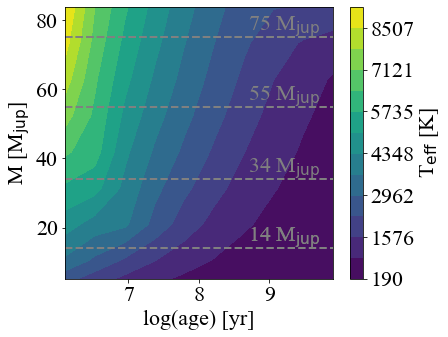

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Z = _teff.reshape(len(M), len(log_age))

M_in_jup = M*M_sun/M_jup

X, Y = np.meshgrid(log_age, M_in_jup)

#levels = np.linspace(np.min(_teff), np.max(_teff), 14)
levels = np.linspace(190, 9200, 14)
print(np.min(_teff), np.max(_teff))

cs = ax.contourf(X, Y, Z, levels=levels)
cbar = fig.colorbar(cs)
cbar.set_label(r"T$_{\rm eff}$ [K]")
ax.axhline(14, color="grey", ls="--", lw=2.)
ax.text(8.7, 77, r"75 M$_{\rm jup}$", color="grey")
ax.text(8.7, 16, r"14 M$_{\rm jup}$", color="grey")
ax.axhline(75, color="grey", ls="--", lw=2.)

ax.text(8.7, 16, r"14 M$_{\rm jup}$", color="grey")
ax.axhline(75, color="grey", ls="--", lw=2.)
ax.text(8.7, 36, r"34 M$_{\rm jup}$", color="grey")
ax.axhline(34, color="grey", ls="--", lw=2.)
ax.text(8.7, 57, r"55 M$_{\rm jup}$", color="grey")
ax.axhline(55, color="grey", ls="--", lw=2.)
#ax.axvline(np.log10(1*10**9))
#ax.axvline(np.log10(2*10**9))
#ax.axvline(np.log10(4.1*10**9))
#ax.axvline(np.log10(8.3*10**9))

ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("log(age) [yr]")

#fig.savefig("../Figs/BD_model_1.pdf", bbox_inches="tight")

(6.0, 10.0)

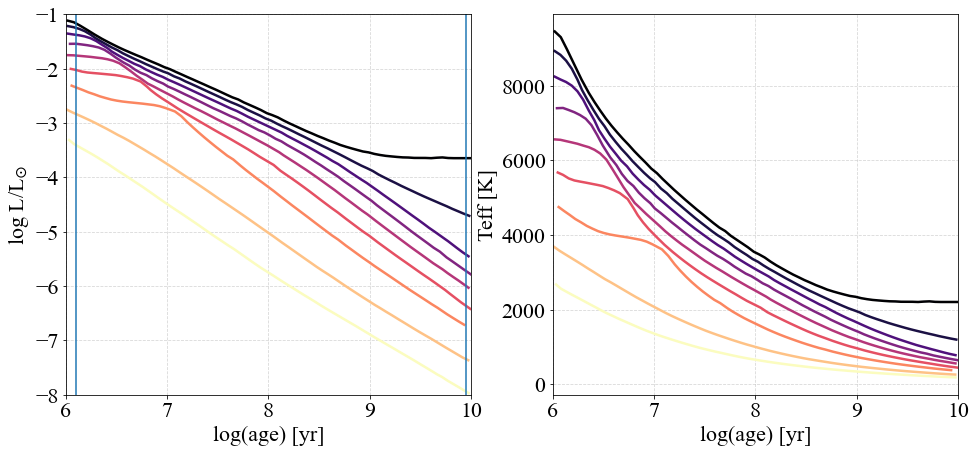

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

colors = bokeh.palettes.magma(len(M))
colors = colors[::-1] # reverse tuple

i = 0
for mass in M:
    ax[0].plot(age[mass], logL[mass], color=colors[i], lw=2.5)
    ax[1].plot(age[mass], Teff[mass], color=colors[i], lw=2.5)
    i = i+1

ax[0].set_ylabel("log L/L$_{\odot}$")
ax[0].set_xlabel("log(age) [yr]")
ax[0].grid(which="both", ls="--", alpha=0.5)
ax[0].set_ylim([-8, -1])
ax[0].set_xlim([6, 10])
ax[0].axvline(6.1)
ax[0].axvline(9.95)

ax[1].set_ylabel("Teff [K]")
ax[1].set_xlabel("log(age) [yr]")
ax[1].grid(which="both", ls="--", alpha=0.5)
ax[1].set_xlim([6, 10])

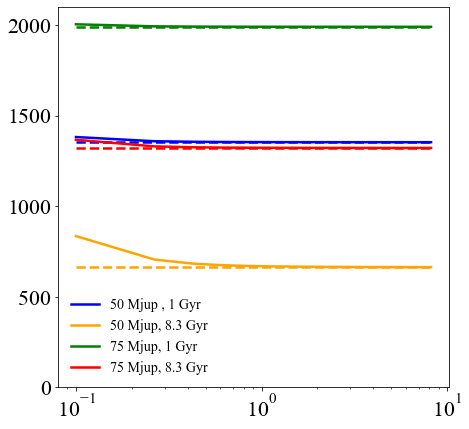

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

r = np.linspace(0.1, 8.178, 50)
m = 50.*M_jup; l_age = 9.
h_int = heat(Teff_interp_2d(l_age, m/M_sun), R_jup.value)
t = temperature_withDM(r, h_int, f=1, R=R_jup.value, M=m, parameters=[1, 20, 0.42])
ax.plot(r, t, label="50 Mjup , 1 Gyr", lw=2.5, color="blue")
ax.plot(r, np.ones(len(r))*Teff_interp_2d(l_age, m/M_sun), ls="--", lw=2.5, color="blue")

m = 50.*M_jup; l_age = 9.92
h_int = heat(Teff_interp_2d(l_age, m/M_sun), R_jup.value)
t = temperature_withDM(r, h_int, f=1, R=R_jup.value, M=m, parameters=[1, 20, 0.42])
ax.plot(r, t, label="50 Mjup, 8.3 Gyr", lw=2.5, color="orange")
ax.plot(r, np.ones(len(r))*Teff_interp_2d(l_age, m/M_sun), ls="--", lw=2.5, color="orange")

m = 75.*M_jup; l_age = 9.
h_int = heat(Teff_interp_2d(l_age, m/M_sun), R_jup.value)
t = temperature_withDM(r, h_int, f=1, R=R_jup.value, M=m, parameters=[1, 20, 0.42])
ax.plot(r, t, label="75 Mjup, 1 Gyr", lw=2.5, color="green")
ax.plot(r, np.ones(len(r))*Teff_interp_2d(l_age, m/M_sun), ls="--", lw=2.5, color="green")

m = 75.*M_jup; l_age = 9.92
h_int = heat(Teff_interp_2d(l_age, m/M_sun), R_jup.value)
t = temperature_withDM(r, h_int, f=1, R=R_jup.value, M=m, parameters=[1, 20, 0.42])
ax.plot(r, t, label="75 Mjup, 8.3 Gyr", lw=2.5, color="red")
ax.plot(r, np.ones(len(r))*Teff_interp_2d(l_age, m/M_sun), ls="--", lw=2.5, color="red")

ax.legend(frameon=False, fontsize=14)
ax.set_ylim([0, 2100])
ax.set_xscale("log")

### ATMO 2020

In [2]:
path   = "../data/evolution_models/ATMO_2020_models/evolutionary_tracks/"
models = ["ATMO_CEQ/", "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]

evolution_ATMO20      = {}
evolution_ATMO20["M"] = []
for model in models:
    evolution_ATMO20[model] = {}
    files = glob.glob(path + model + "*.txt")
    for file in files:
        data = np.genfromtxt(file, unpack=True)
        evolution_ATMO20[model][data[0][0]] = [data[1], data[2], data[3], data[4], data[5]] 
        # age [Gyr] / Teff [K] / L [L/Lsun] / R [R/Rsun] / log g [cm/s2]
        if model==models[0]:
            #print (data[0][0], file)
            evolution_ATMO20["M"].append(data[0][0])

In [6]:
mass = 20*M_jup/M_sun
print(mass)

0.019091884679386502


In [3]:
print (evolution_ATMO20["M"])
print (len(evolution_ATMO20["M"]))

[0.009, 0.035, 0.065, 0.031, 0.071, 0.013, 0.01, 0.044, 0.051, 0.049, 0.039, 0.034, 0.047, 0.0005, 0.046, 0.006, 0.042, 0.028, 0.017, 0.058, 0.014, 0.036, 0.033, 0.055, 0.004, 0.066, 0.054, 0.06, 0.056, 0.024, 0.012, 0.021, 0.027, 0.048, 0.041, 0.032, 0.053, 0.068, 0.03, 0.074, 0.003, 0.016, 0.026, 0.062, 0.023, 0.008, 0.015, 0.019, 0.072, 0.075, 0.043, 0.057, 0.052, 0.029, 0.001, 0.002, 0.018, 0.038, 0.061, 0.05, 0.007, 0.07, 0.022, 0.069, 0.067, 0.063, 0.045, 0.02, 0.073, 0.04, 0.005, 0.011, 0.064, 0.059, 0.037, 0.025]
76


Text(0, 0.5, 'T$_{\\rm eff}$ [K]')

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


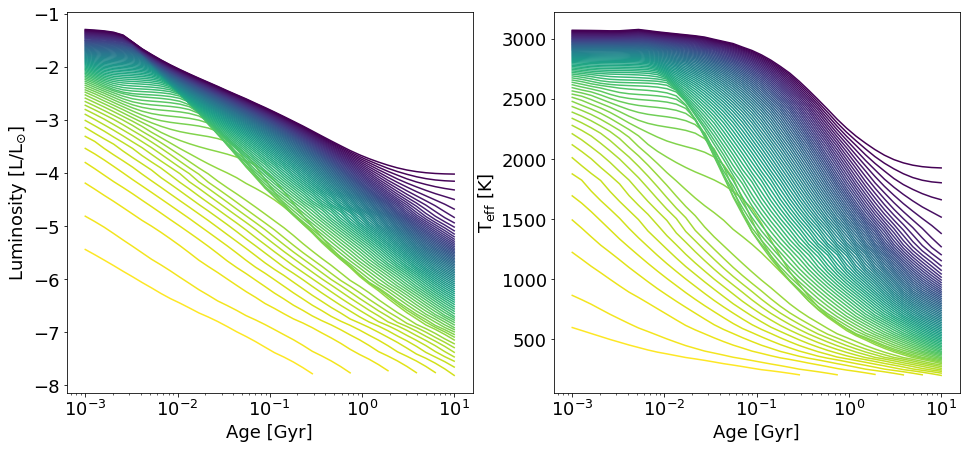

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

i     = 0
ls    = ["-", "--", ":"]
color = bokeh.palettes.viridis(len(evolution_ATMO20["M"]))
color = color[::-1]

models = ["ATMO_CEQ/"]#, "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
masses = np.sort(np.asarray(evolution_ATMO20["M"]))

for model in models:
    j = 0
    for mass in masses:
        #if (np.abs(mass-0.06) < 0.009) or (np.abs(mass-0.07) < 0.009):
        #    print(mass)
        #    continue
        ax[0].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][2], ls=ls[i], color=color[j])
        ax[1].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], ls=ls[i], color=color[j])
        j = j+1
    i = i+1
        
ax[0].set_xlabel("Age [Gyr]")
ax[0].set_xscale("log")
ax[0].set_ylabel(r"Luminosity [L/L$_{\odot}$]")
ax[1].set_xlabel("Age [Gyr]")
ax[1].set_xscale("log")
ax[1].set_ylabel(r"T$_{\rm eff}$ [K]")

In [8]:
masses

array([0.0005, 0.001 , 0.002 , 0.003 , 0.004 , 0.005 , 0.006 , 0.007 ,
       0.008 , 0.009 , 0.01  , 0.011 , 0.012 , 0.013 , 0.014 , 0.015 ,
       0.016 , 0.017 , 0.018 , 0.019 , 0.02  , 0.021 , 0.022 , 0.023 ,
       0.024 , 0.025 , 0.026 , 0.027 , 0.028 , 0.029 , 0.03  , 0.031 ,
       0.032 , 0.033 , 0.034 , 0.035 , 0.036 , 0.037 , 0.038 , 0.039 ,
       0.04  , 0.041 , 0.042 , 0.043 , 0.044 , 0.045 , 0.046 , 0.047 ,
       0.048 , 0.049 , 0.05  , 0.051 , 0.052 , 0.053 , 0.054 , 0.055 ,
       0.056 , 0.057 , 0.058 , 0.059 , 0.06  , 0.061 , 0.062 , 0.063 ,
       0.064 , 0.065 , 0.066 , 0.067 , 0.068 , 0.069 , 0.07  , 0.071 ,
       0.072 , 0.073 , 0.074 , 0.075 ])

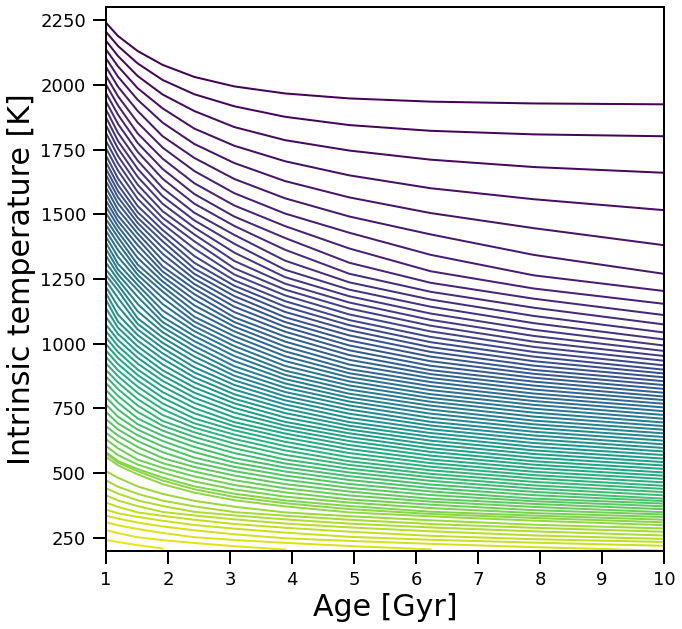

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

i     = 0
ls    = ["-", "--", ":"]
color = bokeh.palettes.viridis(len(evolution_ATMO20["M"]))
color = color[::-1]

models = ["ATMO_CEQ/"]#, "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
masses = np.sort(np.asarray(evolution_ATMO20["M"]))

for model in models:
    j = 0
    for mass in masses:
        #if (np.abs(mass-0.06) < 0.009) or (np.abs(mass-0.07) < 0.009):
        #    print(mass)
        #    continue
        ax.plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], ls=ls[i], color=color[j], lw=2.)
        j = j+1
    i = i+1
 
ax.set_xlabel("Age [Gyr]", fontsize=30)
#ax.set_xscale("log")
ax.set_xlim([1, 10])
ax.set_ylim([200, 2300])
ax.set_ylabel(r"Intrinsic temperature [K]", fontsize=30)

for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.)
        
ax.tick_params(which='major',direction="out",width=2.,length=13,right=False,top=False,pad=7)

#fig.savefig("ATMO_model_masses.pdf", bbox_inches="tight")

200.34531482 1905.1223504655072


findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


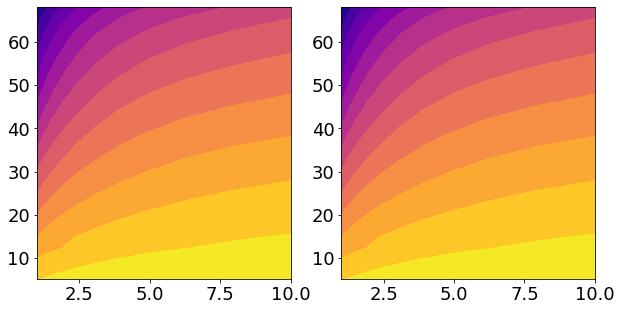

In [6]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 80)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))

points = np.transpose(np.asarray([_age_i, _mass]))
values = np.asarray(_teff)

x, y = np.meshgrid(_age, M)

Teff_interp_2d = griddata(points, values , (x, y))

_teff = np.asarray(_teff)


fig, ax = plt.subplots(1, 2, figsize=(10, 5))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

levels = np.linspace(np.min(_teff), np.max(_teff), 14)
print(np.min(_teff), np.max(_teff))

cs = ax[0].contourf(X, Y, Z, levels=levels, cmap="plasma_r")

ax[1].contourf(X, Y, Teff_interp_2d, levels=levels, cmap="plasma_r")

In [7]:
pos = np.where((np.abs(Y-44.)<0.5) & (X==1.))
print(Y[pos], X[pos])
print(Teff_interp_2d[pos])

[43.99775162] [1.]
[1313.35445654]


/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=88,73 m=6100 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))


200.34531482 1905.1223504655072


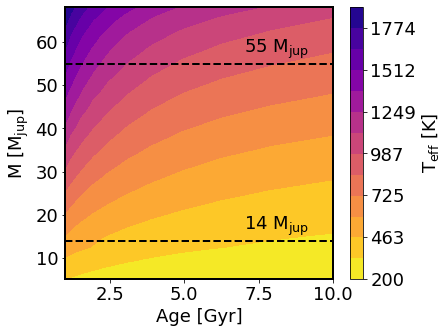

In [6]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
Teff_interp_2d = interp2d(_age_i, _mass, _teff)
_teff = np.asarray(_teff)


fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

levels = np.linspace(np.min(_teff), np.max(_teff), 14)
print(np.min(_teff), np.max(_teff))

cs = ax.contourf(X, Y, Z, levels=levels, cmap="plasma_r")
cbar = fig.colorbar(cs)
cbar.set_label(r"T$_{\rm eff}$ [K]")
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("Age [Gyr]")

for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.)

#fig.savefig("../Figs/ATMO2020_cooling_model.pdf", bbox_inches="tight")

In [12]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
Teff_interp_2d = interp2d(_age_i, _mass, _teff)
_teff = np.asarray(_teff)

In [20]:
# convert K into C
_teff_inC = _teff - 273.15

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


-72.80468517999998 1631.9723504655071


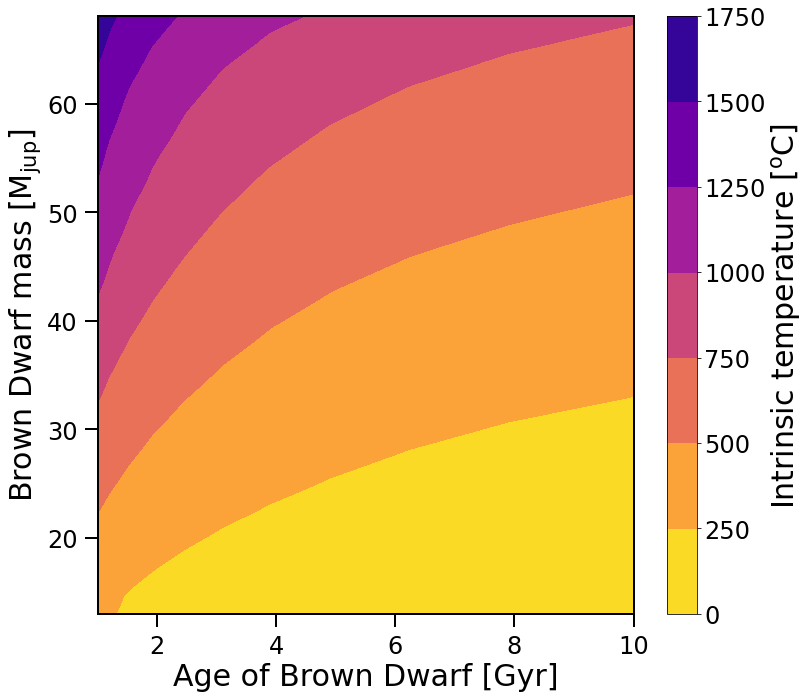

In [47]:
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Palatino'], 'size':24})

fig, ax = plt.subplots(1, 1, figsize=(12, 11))

ax.tick_params(which='major',direction="out",width=2.,length=13,right=False,top=False,pad=7)


Z = _teff_inC.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

pos = np.where(X>13)

levels = np.linspace(0, 1750, 8)
print(np.min(_teff_inC), np.max(_teff_inC))

cs = ax.contourf(X, Y, Z, levels=levels, cmap="plasma_r")
cbar = fig.colorbar(cs)
cbar.set_label(r"Intrinsic temperature [$^{\rm o}$C]", fontsize=30)

ax.set_ylabel(r"Brown Dwarf mass [M$_{\rm jup}$]", fontsize=30)
ax.set_xlabel("Age of Brown Dwarf [Gyr]", fontsize=30)

ax.set_ylim(13, np.max(Y))

for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.)
#fig.savefig("ATMO_model_celsius.pdf", bbox_inches="tight")

200.34531482 1905.1223504655072


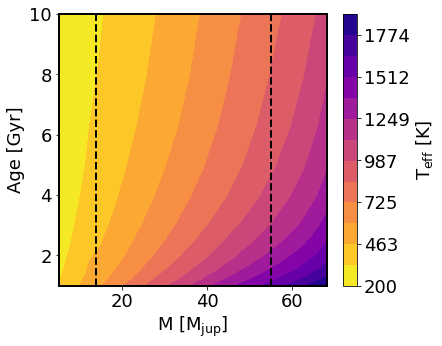

In [7]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
Teff_interp_2d = interp2d(_age_i, _mass, _teff)
_teff = np.asarray(_teff)


fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(M_in_jup, _age)

levels = np.linspace(np.min(_teff), np.max(_teff), 14)
print(np.min(_teff), np.max(_teff))

cs = ax.contourf(X, Y, Z.T, levels=levels, cmap="plasma_r")
cbar = fig.colorbar(cs)
cbar.set_label(r"T$_{\rm eff}$ [K]")
ax.axvline(14, color="k", ls="--", lw=2.)
#ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
#ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axvline(55, color="k", ls="--", lw=2.)

ax.set_xlabel(r"M [M$_{\rm jup}$]")
ax.set_ylabel("Age [Gyr]")

for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.)

#fig.savefig("../Figs/ATMO2020_cooling_model.pdf", bbox_inches="tight")

In [18]:
pos = np.where(Z >= 650.)
print(pos, Z.shape, Z[pos].shape)

(array([12, 13, 13, ..., 60, 60, 60]), array([ 0,  0,  1, ..., 97, 98, 99])) (61, 100) (3312,)


/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=88,73 m=6100 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))


200.34531482 1905.1223504655072


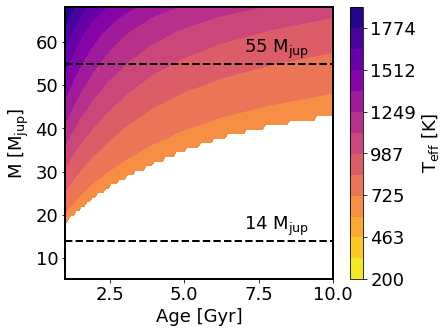

In [25]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
Teff_interp_2d = interp2d(_age_i, _mass, _teff)
_teff = np.asarray(_teff)


fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

levels = np.linspace(np.min(_teff), np.max(_teff), 14)
print(np.min(_teff), np.max(_teff))


Z = np.ma.array(Z, mask=Z < 650.)
cs = ax.contourf(X, Y, Z, levels=levels, cmap="plasma_r")
cbar = fig.colorbar(cs)
cbar.set_label(r"T$_{\rm eff}$ [K]")
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("Age [Gyr]")

for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.)

fig.savefig("/home/mariacst/exoplanets/Figs/ATMO2020_cooling_model_mask650.pdf", bbox_inches="tight")

In [ ]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
Teff_interp_2d = interp2d(_age_i, _mass, _teff)
_teff = np.asarray(_teff)


fig, ax = plt.subplots(1, 1, figsize=(6, 5))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

levels = np.linspace(np.min(_teff), np.max(_teff), 14)
print(np.min(_teff), np.max(_teff))

cs = ax.contourf(X, Y, Z, levels=levels, cmap="plasma_r")
cbar = fig.colorbar(cs)
cbar.set_label(r"T$_{\rm eff}$ [K]")
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("Age [Gyr]")

for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2.)

#fig.savefig("../Figs/ATMO2020_cooling_model.pdf", bbox_inches="tight")

In [71]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-10] # the first 5 masses do not have all values between 1 and 10 Gyr
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
points = np.transpose(np.asarray([_age_i, _mass]))
values = np.asarray(_teff)

_age = _age[0:len(M)]
print(_age.shape, M.shape)
xi = np.transpose(np.asarray([_age, M]))

Teff_interp_2d = griddata(points, values , xi)

(61,) (61,)


Text(0, 0.5, 'Radius [$\\rm R_{Jup}$]')

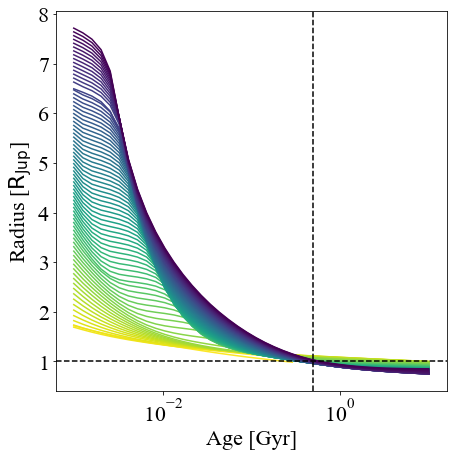

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

i     = 0
ls    = ["-", "--", ":"]
color = bokeh.palettes.viridis(len(evolution_ATMO20["M"]))
color = color[::-1]

models = ["ATMO_CEQ/"]#, "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
masses = np.sort(np.asarray(evolution_ATMO20["M"]))

for model in models:
    j = 0
    for mass in masses:
        #if (np.abs(mass-0.06) < 0.009) or (np.abs(mass-0.07) < 0.009):
        #    print(mass)
        #    continue
        ax.plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][3]*R_sun/R_jup, 
                ls=ls[i], color=color[j])
        j = j+1
    i = i+1

ax.axvline(0.5, color="k", ls="--") # 500 Myr
ax.axhline(1, color="k", ls="--")
        
ax.set_xlabel("Age [Gyr]")
ax.set_xscale("log")
ax.set_ylabel(r"Radius [$\rm R_{Jup}$]") # CHANGE

Text(0, 0.5, 'T$_{\\rm eff}$ [K]')

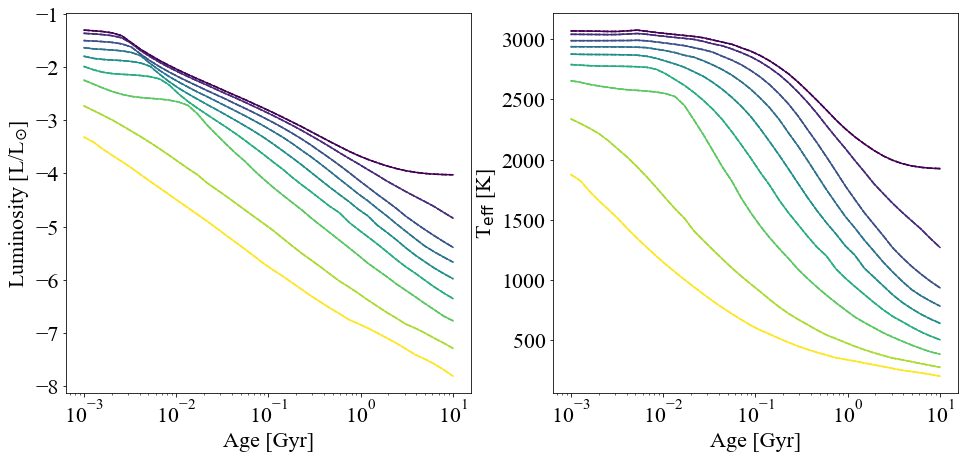

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

i     = 0
ls    = ["-", "--", ":"]



models = ["ATMO_CEQ/", "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
masses = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.075]
color  = bokeh.palettes.viridis(len(masses))
color  = color[::-1]

for model in models:
    j = 0
    for mass in masses:
        #if (np.abs(mass-0.06) < 0.009) or (np.abs(mass-0.07) < 0.009):
        #    print(mass)
        #    continue
        ax[0].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][2], ls=ls[i], color=color[j])
        ax[1].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], ls=ls[i], color=color[j])
        j = j+1
    i = i+1
        
ax[0].set_xlabel("Age [Gyr]")
ax[0].set_xscale("log")
ax[0].set_ylabel(r"Luminosity [L/L$_{\odot}$]")
ax[1].set_xlabel("Age [Gyr]")
ax[1].set_xscale("log")
ax[1].set_ylabel(r"T$_{\rm eff}$ [K]")

**L <--> Teff mapping**

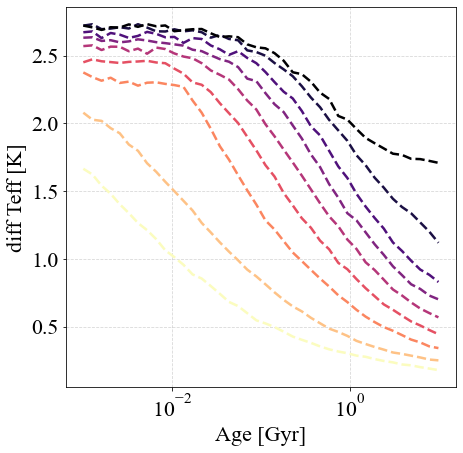

In [141]:
models = ["ATMO_CEQ/"]#, "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
masses = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.075]
T      = {}
colors = bokeh.palettes.magma(len(M))
colors = colors[::-1]

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

for model in models:
    i = 0
    for mass in masses:
        T[mass] = temperature(10**evolution_ATMO20[model][mass][2]*L_sun.value, evolution_ATMO20[model][mass][3]*R_sun.value)
        ax.plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1]-T[mass].value, color=colors[i], lw=2.5, ls="--")
        #ax.plot(evolution_ATMO20[model][mass][0], T[mass], color=colors[i], lw=2.5, ls="--")
        i = i+1
        
ax.set_ylabel("diff Teff [K]")
ax.set_xlabel("Age [Gyr]")
ax.grid(which="both", ls="--", alpha=0.5)
#ax.set_ylim([0, 8000])
ax.set_xscale("log")

### All

dict_keys([0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08])


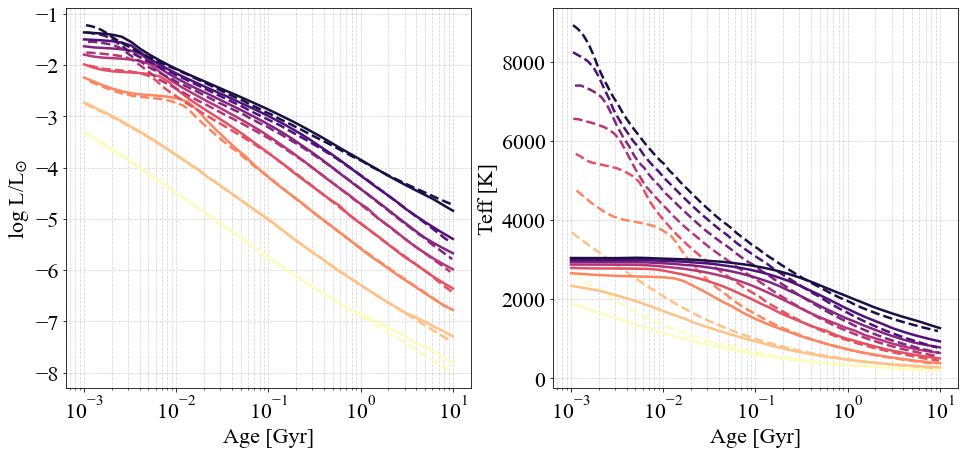

In [121]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))


M = evolution_SM08.keys()
print(M)

colors = bokeh.palettes.magma(len(M))
colors = colors[::-1] # reverse tuple
model  = "ATMO_CEQ/"

i = 0
for mass in M:
    if np.abs(mass-0.08) < 0.001:
        continue
    ax[0].plot(evolution_SM08[mass][0]/1e9, evolution_SM08[mass][2], color=colors[i], lw=2.5, ls="--")
    ax[1].plot(evolution_SM08[mass][0]/1e9, evolution_SM08[mass][1], color=colors[i], lw=2.5, ls="--")
    try:
        ax[0].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][2], color=colors[i], lw=2.5, ls="-")
        ax[1].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], color=colors[i], lw=2.5, ls="-")
    except:
        print(mass)
    i = i+1

ax[0].set_ylabel(r"log L/L$_{\odot}$")
ax[0].set_xlabel("Age [Gyr]")
ax[0].grid(which="both", ls="--", alpha=0.5)
ax[0].set_xscale("log")
#ax[0].set_ylim([-8, -1])
#ax[0].set_xlim([6, 10])

ax[1].set_ylabel("Teff [K]")
ax[1].set_xlabel("Age [Gyr]")
ax[1].grid(which="both", ls="--", alpha=0.5)
#ax[1].set_xlim([6, 10])
ax[1].set_xscale("log")

dict_keys([0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08])


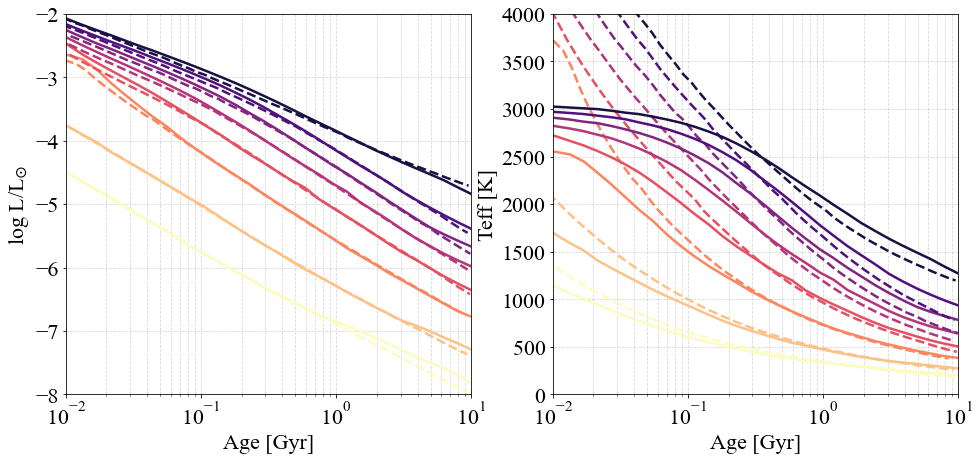

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))


M = evolution_SM08.keys()
print(M)

colors = bokeh.palettes.magma(len(M))
colors = colors[::-1] # reverse tuple
model  = "ATMO_CEQ/"

i = 0
for mass in M:
    if np.abs(mass-0.08) < 0.001:
        continue
    ax[0].plot(evolution_SM08[mass][0]/1e9, evolution_SM08[mass][2], color=colors[i], lw=2.5, ls="--")
    ax[1].plot(evolution_SM08[mass][0]/1e9, evolution_SM08[mass][1], color=colors[i], lw=2.5, ls="--")
    try:
        ax[1].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], color=colors[i], lw=2.5, ls="-")
        ax[0].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][2], color=colors[i], lw=2.5, ls="-")
    except:
        print(mass)
    i = i+1

ax[0].set_ylabel("log L/L$_{\odot}$")
ax[0].set_xlabel("Age [Gyr]")
ax[0].grid(which="both", ls="--", alpha=0.5)
ax[0].set_xscale("log")
ax[0].set_ylim([-8, -2.])
ax[0].set_xlim([0.01, 10])

ax[1].set_ylabel("Teff [K]")
ax[1].set_xlabel("Age [Gyr]")
ax[1].grid(which="both", ls="--", alpha=0.5)
ax[1].set_xlim([0.01, 10])
ax[1].set_ylim([0, 4000])
ax[1].set_xscale("log")

## Tmin cuts

In [4]:
import mock_generation
imp.reload(mock_generation)

from mock_generation import mock_population

N = 100; gamma=1.5; rs = 20.; f = 1.

robs0, Tobs0_wn, Tobs0, mass0_wn, mass0, ages0 = mock_population(N, 0.10, 0.10, f, gamma, rs, Tmin=650.)
robs1, Tobs1_wn, Tobs1, mass1_wn, mass1, ages1 = mock_population(N, 0.10, 0.20, f, gamma, rs, Tmin=650.)
robs2, Tobs2_wn, Tobs2, mass2_wn, mass2, ages2 = mock_population(N, 0.20, 0.20, f, gamma, rs, Tmin=650.)
robs3, Tobs3_wn, Tobs3, mass3_wn, mass3, ages3 = mock_population(N, 0.30, 0.30, f, gamma, rs, Tmin=650.)

In [5]:
print(np.std((mass0-mass0_wn)/mass0)*100)
print(np.std((mass1-mass1_wn)/mass0)*100)
print(np.std((mass2-mass2_wn)/mass0)*100)

print("")

print(np.std((Tobs0-Tobs0_wn)/Tobs0)*100)
print(np.std((Tobs1-Tobs1_wn)/Tobs0)*100)
print(np.std((Tobs2-Tobs2_wn)/Tobs0)*100)

10.000029417970637
20.469948717208798
23.82697543992639

9.632579734976298
10.493476220007993
20.308365795001475


200.34531482 2205.1801623104056


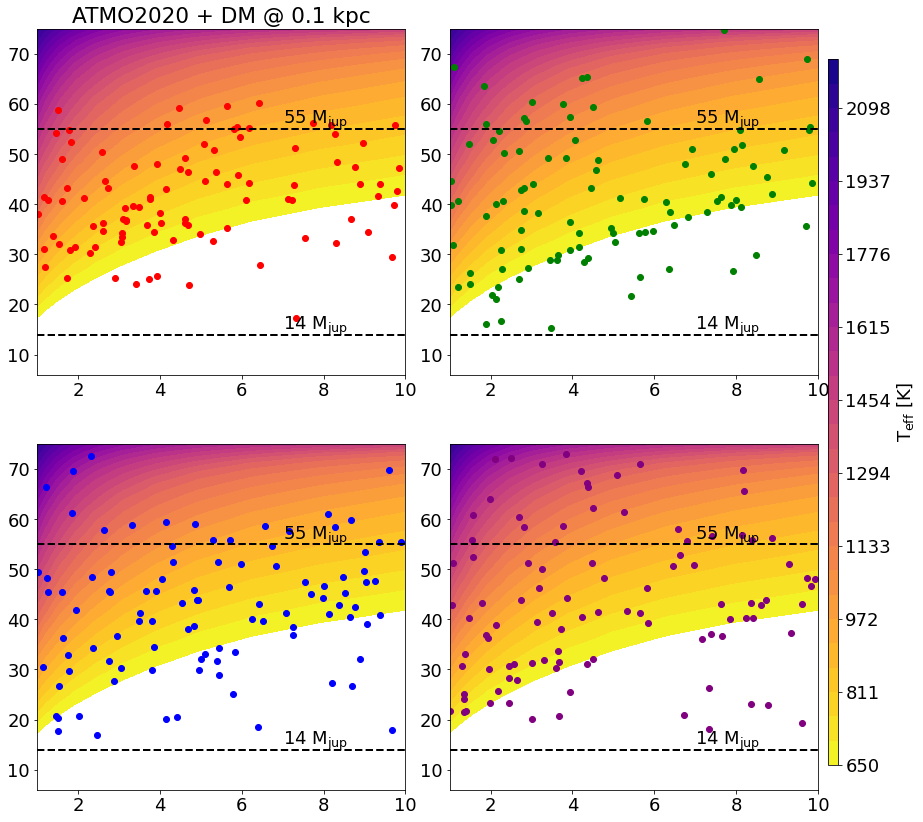

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

#levels = np.linspace(np.min(_teff), np.max(_teff), 14)
levels = np.linspace(650., np.max(_teff), 30)
print(np.min(_teff), np.max(_teff))
            
ax = axes[0, 0]
heat_int = heat(Z.ravel(), np.ones(len(Z.ravel()))*R_jup.value)
T_DM     = temperature_withDM(1., heat_int, f=1., R=R_jup.value, M=Y.ravel()*M_jup.value, parameters=[1.5, 20., 0.42])
Z_DM     = T_DM.reshape(Z.shape)
ax.set_title("ATMO2020 + DM @ 0.1 kpc")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

im = ax.contourf(X, Y, Z_DM, levels=levels, cmap="plasma_r")
ax.scatter(ages0, mass0*M_sun.value/M_jup.value, color="red")

ax = axes[0, 1]
ax.contourf(X, Y, Z_DM, levels=levels, cmap="plasma_r")
ax.scatter(ages1, mass1*M_sun.value/M_jup.value, color="green")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15., r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56., r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

ax = axes[1, 0]
ax.contourf(X, Y, Z_DM, levels=levels, cmap="plasma_r")
ax.scatter(ages2, mass2*M_sun.value/M_jup.value, color="blue")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15., r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56., r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

ax = axes[1, 1]
ax.contourf(X, Y, Z_DM, levels=levels, cmap="plasma_r")
ax.scatter(ages3, mass3*M_sun.value/M_jup.value, color="purple")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15., r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56., r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"T$_{\rm eff}$ [K]")

fig.subplots_adjust(wspace=0.12)

In [7]:
path   = "../data/evolution_models/ATMO_2020_models/evolutionary_tracks/"
models = ["ATMO_CEQ/"]

evolution_ATMO20      = {}
evolution_ATMO20["M"] = []
for model in models:
    evolution_ATMO20[model] = {}
    files = glob.glob(path + model + "*.txt")
    for file in files:
        data = np.genfromtxt(file, unpack=True)
        evolution_ATMO20[model][data[0][0]] = [data[1], data[2], data[3], data[4], data[5]] 
        # age [Gyr] / Teff [K] / L [L/Lsun] / R [R/Rsun] / log g [cm/s2]
        if model==models[0]:
            #print (data[0][0], file)
            evolution_ATMO20["M"].append(data[0][0])

In [8]:
model = "ATMO_CEQ/"
age   = {}
M     = np.sort(evolution_ATMO20["M"])[5:-1]
Teff  = {}

for mass in M:
    age[mass]  = evolution_ATMO20[model][mass][0]
    Teff[mass] = evolution_ATMO20[model][mass][1]

_age   = np.linspace(1, 10, 100)    
_teff  = [] ; _age_i = []; _mass  = []
for m in M:
    Teff_interp = interp1d(age[m], Teff[m])
    for _a in _age:
        _age_i.append(_a)
        _mass.append(m)
        _teff.append(Teff_interp(_a))
        
Teff_interp_2d = interp2d(_age_i, _mass, _teff)
_teff = np.asarray(_teff)

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=92,80 m=7000 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))


200.34531482 2205.1801623104056


findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


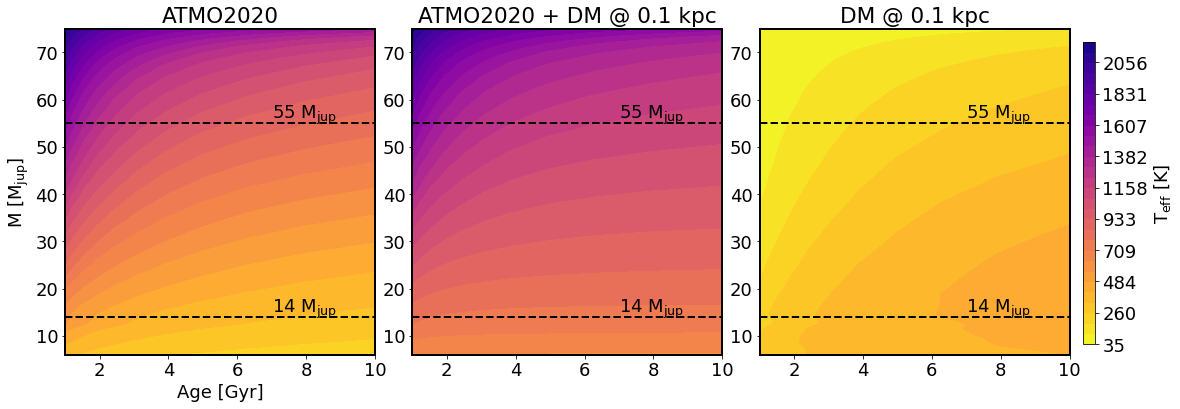

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

#levels = np.linspace(np.min(_teff), np.max(_teff), 14)
levels = np.linspace(35, np.max(_teff), 30)
print(np.min(_teff), np.max(_teff))

ax = axes[0]
#Z = np.ma.array(Z, mask=Z < 650.)
ax.contourf(X, Y, Z, levels=levels, cmap="plasma_r")
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)
ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("Age [Gyr]")
ax.set_title("ATMO2020")
ax.set_ylim(6, 75)

for ax in axes:
    for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2.)
            
ax = axes[1]
heat_int = heat(Z.ravel(), np.ones(len(Z.ravel()))*R_jup.value)
T_DM     = temperature_withDM(0.1, heat_int, f=1., R=R_jup.value, M=Y.ravel()*M_jup.value, parameters=[1.5, 20., 0.42])
Z_DM     = T_DM.reshape(Z.shape)
ax.set_title("ATMO2020 + DM @ 0.1 kpc")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

ax.contourf(X, Y, Z_DM, levels=levels, cmap="plasma_r")

ax = axes[2]
Z_res = Z_DM-Z
im = ax.contourf(X, Y, Z_res, levels=levels, cmap="plasma_r")
ax.set_title("DM @ 0.1 kpc")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 15., r"14 M$_{\rm jup}$", color="k")
ax.text(7., 56., r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"T$_{\rm eff}$ [K]")

fig.subplots_adjust(wspace=0.12)

In [ ]:
/hdfs/local/mariacst/exoplanets/results/final_round/Tmin/ex12

In [ ]:
/hdfs/local/mariacst/exoplanets/results/final_round/Tmin/ex12

200.34531482 2205.1801623104056


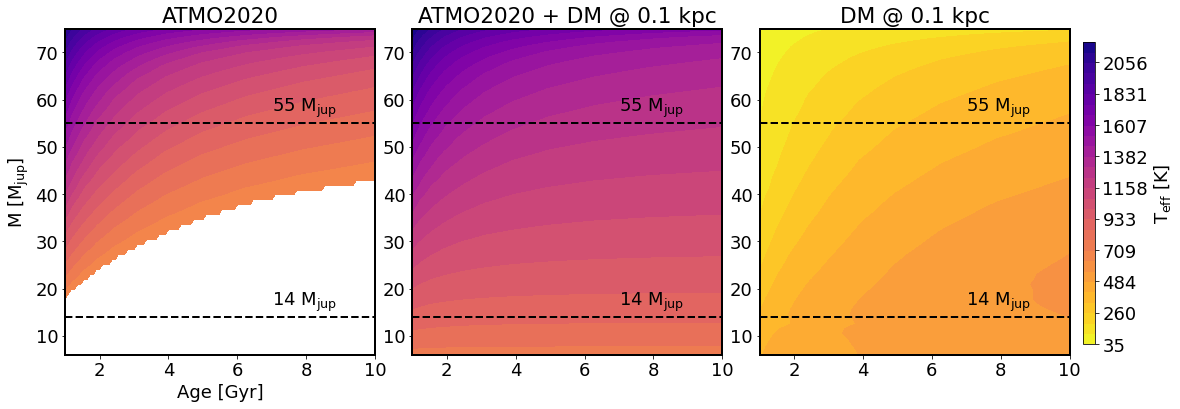

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

#levels = np.linspace(np.min(_teff), np.max(_teff), 14)
levels = np.linspace(35, np.max(_teff), 30)
print(np.min(_teff), np.max(_teff))

ax = axes[0]
Z_mask = np.ma.array(Z, mask=Z < 650.)
ax.contourf(X, Y, Z_mask, levels=levels, cmap="plasma_r")
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)
ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("Age [Gyr]")
ax.set_title("ATMO2020")
ax.set_ylim(6, 75)

for ax in axes:
    for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2.)
            
ax = axes[1]
heat_int = heat(Z.ravel(), np.ones(len(Z.ravel()))*R_jup.value)
T_DM     = temperature_withDM(0.1, heat_int, f=1., R=R_jup.value, M=Y.ravel()*M_jup.value, parameters=[1.5, 5., 0.42])
Z_DM     = T_DM.reshape(Z.shape)
ax.set_title("ATMO2020 + DM @ 0.1 kpc")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

Z_DM_mask = np.ma.array(Z_DM, mask=Z_DM < 650.)
ax.contourf(X, Y, Z_DM_mask, levels=levels, cmap="plasma_r")

ax = axes[2]
Z_res = Z_DM-Z
im = ax.contourf(X, Y, Z_res, levels=levels, cmap="plasma_r")
ax.set_title("DM @ 0.1 kpc")
ax.set_ylim(6, 75)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"T$_{\rm eff}$ [K]")

fig.subplots_adjust(wspace=0.12)

200.34531482 2205.1801623104056


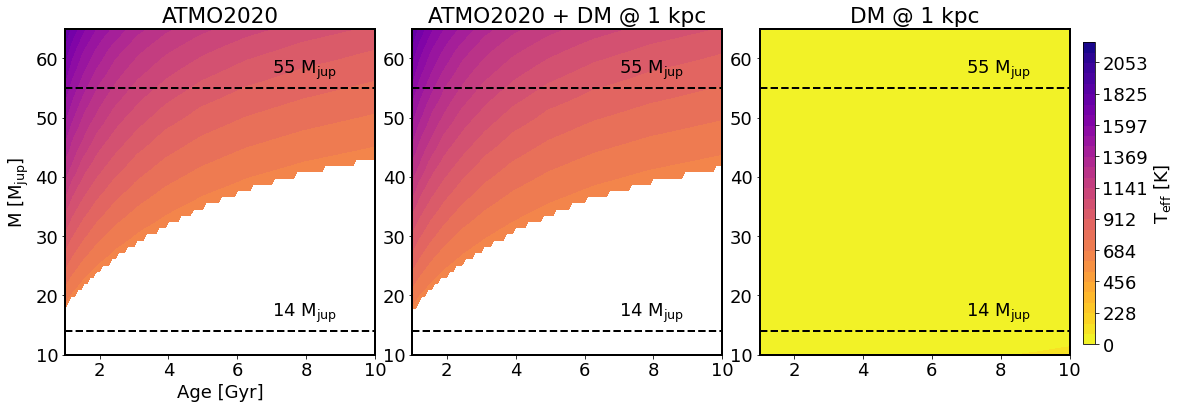

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

#levels = np.linspace(np.min(_teff), np.max(_teff), 14)
levels = np.linspace(0, np.max(_teff), 30)
print(np.min(_teff), np.max(_teff))

ax = axes[0]
Z_mask = np.ma.array(Z, mask=Z < 650.)
ax.contourf(X, Y, Z_mask, levels=levels, cmap="plasma_r")
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)
ax.set_ylabel(r"M [M$_{\rm jup}$]")
ax.set_xlabel("Age [Gyr]")
ax.set_title("ATMO2020")
ax.set_ylim(10, 65)

for ax in axes:
    for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2.)
            
ax = axes[1]
heat_int = heat(Z.ravel(), np.ones(len(Z.ravel()))*R_jup.value)
T_DM     = temperature_withDM(1., heat_int, f=1., R=R_jup.value, M=Y.ravel()*M_jup.value, parameters=[1.5, 5., 0.42])
Z_DM     = T_DM.reshape(Z.shape)
ax.set_title("ATMO2020 + DM @ 1 kpc")
ax.set_ylim(10, 65)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

Z_DM_mask = np.ma.array(Z_DM, mask=Z_DM < 650.)
ax.contourf(X, Y, Z_DM_mask, levels=levels, cmap="plasma_r")

ax = axes[2]
Z_res = Z_DM-Z
im = ax.contourf(X, Y, Z_res, levels=levels, cmap="plasma_r")
ax.set_title("DM @ 1 kpc")
ax.set_ylim(10, 65)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"T$_{\rm eff}$ [K]")

fig.subplots_adjust(wspace=0.12)

200.34531482 2205.1801623104056


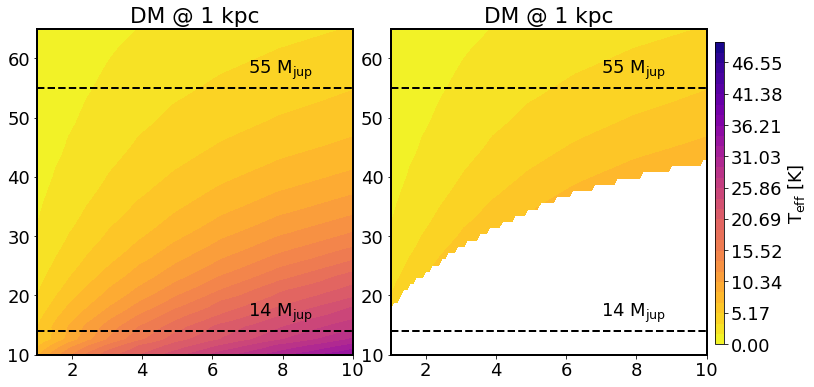

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

Z = _teff.reshape(len(M), len(_age))
M_in_jup = M*M_sun/M_jup
X, Y = np.meshgrid(_age, M_in_jup)

#levels = np.linspace(np.min(_teff), np.max(_teff), 14)
levels = np.linspace(0, 50., 30)
print(np.min(_teff), np.max(_teff))

ax = axes[0]

heat_int  = heat(Z.ravel(), np.ones(len(Z.ravel()))*R_jup.value)
T_DM      = temperature_withDM(1., heat_int, f=1., R=R_jup.value, M=Y.ravel()*M_jup.value, parameters=[1.3, 20., 0.42])
Z_DM      = T_DM.reshape(Z.shape)
Z_DM_mask = np.ma.array(Z_DM, mask=Z_DM < 650.)

Z_res = Z_DM-Z
im = ax.contourf(X, Y, Z_res, levels=levels, cmap="plasma_r")
ax.set_title("DM @ 1 kpc")
ax.set_ylim(10, 65)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

for ax in axes:
    for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2.)
            
ax = axes[1]
Z_res = Z_DM_mask-Z
im = ax.contourf(X, Y, Z_res, levels=levels, cmap="plasma_r")
ax.set_title("DM @ 1 kpc")
ax.set_ylim(10, 65)
ax.axhline(14, color="k", ls="--", lw=2.)
ax.text(7., 16.5, r"14 M$_{\rm jup}$", color="k")
ax.text(7., 57.5, r"55 M$_{\rm jup}$", color="k")
ax.axhline(55, color="k", ls="--", lw=2.)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"T$_{\rm eff}$ [K]")

fig.subplots_adjust(wspace=0.12)

In [25]:
mass = 0.019
i=36
age = evolution_ATMO20[model][mass][0][i]    
Tint = evolution_ATMO20[model][mass][1][i]
print(age, Tint)

4.92388263 443.31075863


In [26]:
print (0.019*M_sun)

3.7779787543262966e+28 kg


In [24]:
help(temperature_withDM)

Help on function temperature_withDM in module utils:

temperature_withDM(r, Tint, R=71492000.0, M=1.8981245973360505e+27, f=1.0, p=[1.0, 20.0, 0.42], v=None, Rsun=8.178, epsilon=1)
    Exoplanet temperature : internal heating + DM heating



In [36]:
T = temperature_withDM(0.1, Tint, M=(0.019*M_sun.value), p=[1.2, 20., 0.42], v=100.)
print(T)

625.7890491524468


In [48]:
import imp
import utils
imp.reload(utils)

from utils import T_DM

help(T_DM)

Help on function T_DM in module utils:

T_DM(r, R=71492000.0, M=1.8981245973360505e+27, Rsun=8.178, f=1.0, params=[1.0, 20.0, 0.42], v=None, epsilon=1.0)
    DM temperature [K]



In [49]:
T_DM = T_DM(0.1, M=(0.019*M_sun.value), params=[1.2, 20., 0.42], v=100.)

In [50]:
print(T_DM, (T_DM**4 + Tint**4)**0.25)

582.0052090176686 625.7890491524468


In [38]:
from utils import heat_DM

help(heat_DM)

Help on function heat_DM in module utils:

heat_DM(r, f=1, R=71492000.0, M=1.8981245973360505e+27, Rsun=8.178, parameters=[1.0, 20.0, 0.42], v=None)
    Heat flow due to DM capture and annihilation



In [39]:
heat_DM(0.1, M=(0.019*M_sun.value), parameters=[1.2, 20., 0.42], v=100.)

4.1787268215069947e+20

In [53]:
G

<<class 'astropy.constants.codata2018.CODATA2018'> name='Gravitational constant' value=6.6743e-11 uncertainty=1.5e-15 unit='m3 / (kg s2)' reference='CODATA 2018'>